The **NL2SH-ALFA** dataset is a high-fidelity collection of ~40,000 pairs from MIT-CSAIL that prioritizes "functional equivalence"—meaning it focuses on whether a command actually works rather than just matching text patterns. It is heavily biased toward **Linux/GNU environments**, so it often relies on utilities and flags that aren't natively compatible with macOS. Regarding safety: **yes, it contains "dangerous" commands.** It includes operations like `rm -rf`, file overwrites (`>`), and disk partitioning, as it is designed to teach a model how to be a literal system administrator. It lacks an inherent "moral compass," so if a user asks it to delete their home directory, it will provide the exact command to do so; you'll need to implement your own safety guardrails during deployment.

In [28]:
from random import randint
from datasets import load_dataset


import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [3]:
train_ds = load_dataset("westenfelder/NL2SH-ALFA", "train")
test_ds = load_dataset("westenfelder/NL2SH-ALFA", "test")

In [4]:
train_ds

DatasetDict({
    train: Dataset({
        features: ['nl', 'bash'],
        num_rows: 40639
    })
})

In [5]:
train_ds["train"][5]

{'nl': 'show the last date and time the system was rebooted', 'bash': 'who -b'}

In [6]:
# this command does not work in mac
random_index = randint(0, len(train_ds["train"]) - 1)
print(f"Goal: {train_ds['train'][random_index]['nl']}")
print(f"Command: {train_ds['train'][random_index]['bash']}")

Goal: Create an AWS cost and usage report definition from a JSON file
Command: aws cur put-report-definition --report-definition file://path/to/report_definition.json


In [7]:
# this command does not work in mac
random_index = randint(0, len(train_ds["train"]) - 1)
print(f"Goal: {train_ds['train'][random_index]['nl']}")
print(f"Command: {train_ds['train'][random_index]['bash']}")

Goal: Find all files in the current directory and its subdirectories, and create a tar archive called "backup.tar" containing all of them.
Command: find ./ -name "*" | xargs tar -cf backup.tar


In [12]:
df = pd.DataFrame(train_ds["train"])

In [13]:
# the first word is generally a verb, extract the first word of every command and plot a frequency bar chart.
df["utility"] = df["bash"].apply(
    lambda x: x.split()[0] if len(x.split()) > 0 else "unknown"
)

# bash command contain these characters, generally indicates complexity
df["pipe_count"] = df["bash"].apply(lambda x: x.count("|"))
df["redirect_count"] = df["bash"].apply(lambda x: x.count(">") + x.count(">>"))
df["nl_len"] = df["nl"].apply(lambda x: len(str(x).split()))
df["bash_len"] = df["bash"].apply(lambda x: len(str(x).split()))

# dangerous commands
danger_patterns = [
    r"rm\s+-rf",
    r"mkfs",
    r">\s+/dev/sd",
    r"dd\s+if=",
    r"chmod\s+-R\s+777",
]
df["is_dangerous"] = df["bash"].apply(
    lambda x: any(re.search(p, x) for p in danger_patterns)
)

In [14]:
df.head()

,nl,bash,utility,pipe_count,redirect_count,nl_len,bash_len,is_dangerous
0,show the free space on all filesystems,df -h,df,0,0,7,2,False
1,lists the name and pids of the top 5 processes...,"ps -eo pid,comm,%cpu --sort=-%cpu | head -n 6",ps,1,0,15,8,False
2,shows how much free memory a system has,free -h,free,0,0,8,2,False
3,shows how much free space there is on the root...,df -h /,df,0,0,11,3,False
4,shows the disk space used by the directory /va...,du -sh /var/log,du,0,0,9,3,False


In [16]:
df[df.is_dangerous].tail(25)

,nl,bash,utility,pipe_count,redirect_count,nl_len,bash_len,is_dangerous
39384,Find all files in the /var/log directory that ...,find /var/log -mtime +7 -exec rm -rf {} \;,find,0,0,18,9,True
39423,Find all files with the extension .mp3 in the ...,"echo ""\\$(find / -name '*.mp3' -exec rm -rf {}...",echo,0,0,14,10,True
39443,Search the entire file system for files with t...,"find / -iname ""*.log"" | rm -rf",find,1,0,14,7,True
39538,Delete (recursively) a randomly chosen file wi...,rm -rf $(find / -name '*.txt' | shuf -n 1),rm,1,0,16,10,True
39612,Find any files larger than 200MB and delete th...,find . -size +200M -exec rm -rf {} \;,find,0,0,10,9,True
39689,Find all files of type 's' (symbolic link) in ...,find /usr -type s -size 32c -exec rm -rf {} \;,find,0,0,21,11,True
39709,Find all files with the extension .mp3 and del...,find / -name '*.mp3' -exec rm -rf {} \;,find,0,0,17,9,True
39910,Find all files (not directories) that are not ...,find . -not -path '*/\.*' -type f -exec rm -rf...,find,0,0,12,12,True
39918,Find all files in the home directory that end ...,find $HOME/ -name '*.ex*' | xargs rm -rf,find,1,0,18,8,True
39933,Remove (recursively) the most recently created...,rm -rf $(ls -td */ | head -n1),rm,1,0,7,8,True


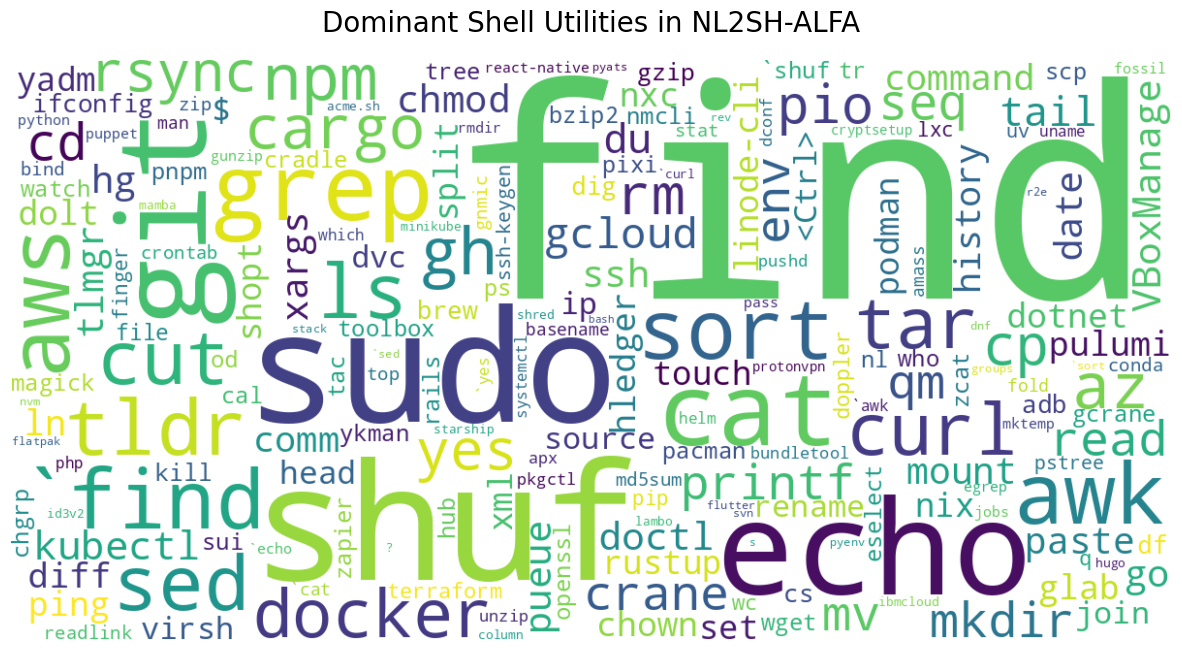

In [ ]:
utility_counts = df["utility"].value_counts().to_dict()

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
).generate_from_frequencies(utility_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Dominant Shell Utilities in NL2SH-ALFA", fontsize=20, pad=20)
plt.show()

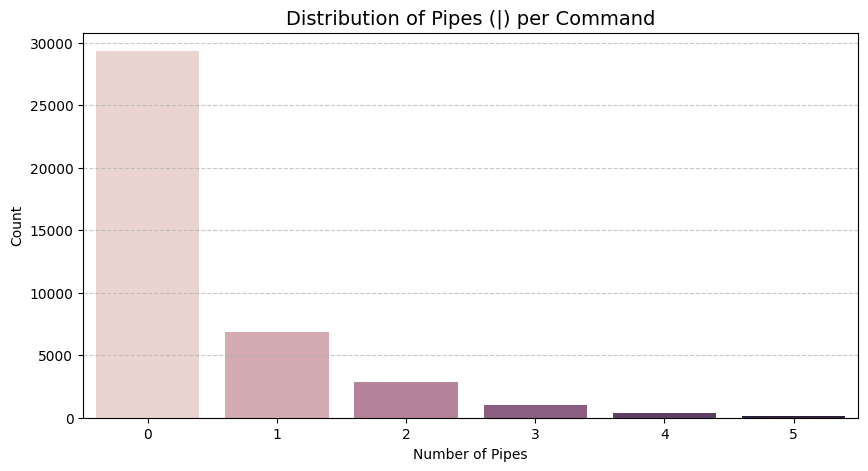

In [ ]:
# the more we have pipe the more complex the command is
plt.figure(figsize=(10, 5))
sns.countplot(
    x="pipe_count", data=df[df["pipe_count"] <= 5], hue="pipe_count", legend=False
)
plt.title("Distribution of Pipes (|) per Command", fontsize=14)
plt.xlabel("Number of Pipes")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

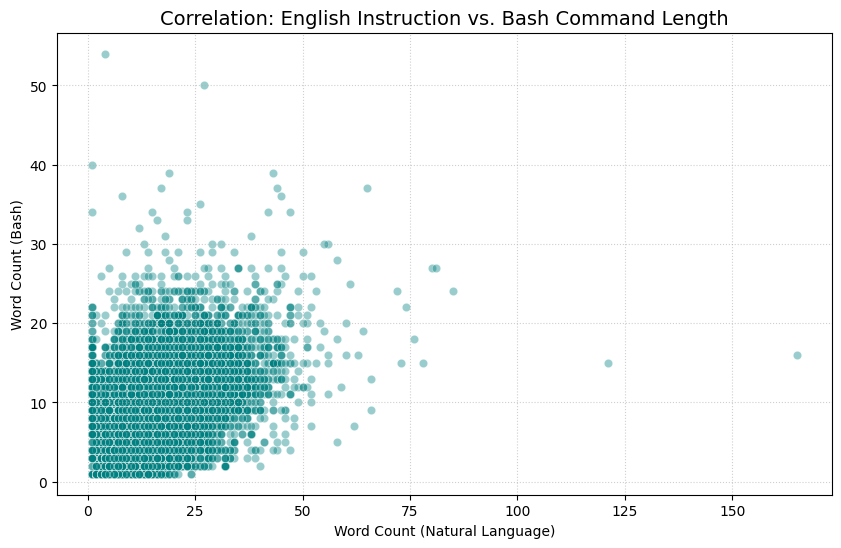

In [ ]:
# we do see some correlation, as the length increases. We maybe having some outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(x="nl_len", y="bash_len", data=df, alpha=0.4, color="teal")
plt.title("Correlation: English Instruction vs. Bash Command Length", fontsize=14)
plt.xlabel("Word Count (Natural Language)")
plt.ylabel("Word Count (Bash)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()